### Asset Report Analysis

This notebook presents an exploratory analysis of U.S. military gaming machine asset reports compiled from multiple standardized CSV formats.

The main objectives are to:
- Clean and harmonize machine-level asset data across reporting formats.
- Analyze category trends (SLOT, FRS, ACM/ITC) over time and by base/region.
- Examine provider-level market concentration and diversity.
- Generate clear, well-documented exploratory findings to support further statistical and policy analysis.

#### Import Necessary Modules and Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import calendar
from datetime import datetime, date
from pathlib import Path
from IPython.display import display, HTML
import re
import json

VERBOSE = False  # set to True when debugging

def vprint(*args, **kwargs):
    if VERBOSE:
        print(*args, **kwargs)

#### Set Global Plotting Settings and Paramters

In [61]:
# Matplotlib + Seaborn style
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

# Centralized figure sizes
FIGSIZE_LANDSCAPE = (10, 5)
FIGSIZE_LANDSCAPE_WIDE = (12, 6)
FIGSIZE_SQUARE = (6, 6)

# Centralized font sizes
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 12
TICK_FONTSIZE = 10

#### Import Necessary CSV Data Files

Import all standardized .csv files. These files were derived from the original PDF asset reports supplied by the client. The PDFs were processed using Adobe Express and MuckRock’s provided OCR tools to extract tabular data. Following extraction, the datasets were cleaned and normalized using a combination of manual review, Excel formulas, and scripted preprocessing to ensure consistent formatting across all asset report versions.

The directory structure for the Asset Report Analysis is shown below:
- data
    - Asset Reports
        - Assset Reports Format 1
            - Asset Report FY20 Format 1.xlsx
            - Asset Report FY21 Format 1.xlsx
            - Asset Report FY22 Format 1.xlsx
            - Asset Report FY23 Format 1.xlsx
            - Asset Report FY24 Format 1.xlsx
    - Assset Report FY20-FY24 Format 1.csv
    - Assset Report FY20-FY24 Format 2.csv
    - Assset Report FY20-FY24 Format 4.csv

#### Paths and Directory

We define input/output locations for all Asset Reports.


In [3]:
# Path Directory for Uploaded Asset Reports
asset_report_fmt1_dir = Path("data/Asset Reports/Asset Reports Format 1")
asset_report_fmt1_path = 'data/Asset Reports/Asset Report FY20-FY24 Format 1.csv'
asset_report_2_path = 'data/Asset Reports/Asset Report FY20-FY24 Format 2.csv'
asset_report_4_path = 'data/Asset Reports/Asset Report FY20-FY24 Format 4.csv'

bases_json_path = 'data/bases.json'

##### Read-In Our CSV Data

In this section we load the raw Excel asset report and define helper
functions for parsing header text (titles and reporting dates).


In [4]:
asset_report_fmt1_2020 = pd.read_excel(asset_report_fmt1_dir / "Asset Report FY20 Format 1.xlsx")
asset_report_fmt1_2021 = pd.read_excel(asset_report_fmt1_dir / "Asset Report FY21 Format 1.xlsx")
asset_report_fmt1_2022 = pd.read_excel(asset_report_fmt1_dir / "Asset Report FY22 Format 1.xlsx")
asset_report_fmt1_2023 = pd.read_excel(asset_report_fmt1_dir / "Asset Report FY23 Format 1.xlsx")
asset_report_fmt1_2024 = pd.read_excel(asset_report_fmt1_dir / "Asset Report FY24 Format 1.xlsx")
asset_report_fmt1 = pd.read_csv(asset_report_fmt1_path, low_memory=False)

ar4 = pd.read_csv(asset_report_4_path, low_memory=False)

### Data Preparation and Preliminary Inspection

The original PDF asset reports were separated into five distinct table formats using Adobe Express and the OCR tools provided by MuckRock. Each extracted table was then exported as a standardized .csv file. Because the formats differ in layout, variable definitions, and structural organization, all subsequent steps—inspection, cleaning, and analysis—are carried out individually for each format.

To assess the suitability of the extracted data for analysis, each format undergoes a preliminary inspection. This review includes verification of row and column structure, examination of variable names and inferred data types, inspection of sample records to confirm accurate extraction, generation of descriptive statistics for quantitative fields, and identification of missing values or other irregularities. Conducting this assessment separately for each format establishes an initial understanding of the dataset and facilitates concurrent analytical work across formats.

Following inspection, each dataset proceeds through a cleaning and standardization stage tailored to its structural characteristics. This process involves correcting OCR-related inconsistencies, standardizing variable names and data types, addressing missing or incomplete values, resolving formatting issues, and validating the plausibility of key variables. These procedures ensure that each format is transformed into a coherent and analytically usable dataset.

Once cleaned, the datasets are prepared for format-specific analytical workflows. Depending on the structure of each format, this may include generating derived variables, restructuring tables through aggregation or pivoting, validating internal consistency, and creating summary outputs. When formats share comparable variables, results may also be synthesized to support broader comparative analysis.

### Format 1

#### 1. Helper Functions (Data Cleaning and Processing)

The helper functions below implement the core parsing and standardization logic for the Format 1 asset reports. They are used throughout the rest of the notebook, but are all defined here in one place for clarity and reproducibility.

- functions `load_raw` and `row_to_text` handle loading OCR-extracted sheets from Excel and normalizing each row into a single, cleaned text string (stripping whitespace and placeholder values like `"nan"`).

- function `find_all_field_office_titles` scans the raw sheet to locate every row that contains a `"EGMs by Field Office"` or `"Assets by Field Office"` table title.

- function `parse_reporting_date_below` walks downward from each title row and extracts the reporting date from nearby header text, handling both exact dates (e.g.`"as of 27 March 2020"`) and month-end summaries (e.g. `"for month of March 2020"` or `"as of EOM March 2021"`).

- function `parse_field_office_block` parses each “Field Office” block row by row: it detects region headers (Europe, Japan, Korea), extracts `Field_Office_ID` and `Field_Office_Name`, and then cleans the numeric section into `Slots`, `ACM`, `ITC`, `FRS`, and `Total`.  During this step it also strips note text such as `"s/b 150"` and treats bare dashes `"-"` as 0, which appear in a few OCR’d rows.

- function `parse_single_fmt1_file` wraps the above helpers for one Excel workbook: it loads the raw sheet, finds all title rows, pairs each block with its reporting date, and returns a list of structured field-office records for that file (while printing the detected title rows, date rows, and number of parsed records).

- functions `build_canonical_names` and `enforce_canonical_names` standardize `Field_Office_Name` across spelling and OCR variants using a reference list in `bases.json`, so that each `(Region, Field_Office_ID)` pair has a single canonical name.

- function `add_coordinates` attaches longitude (`lon`) and latitude (`lat`) from the `bases.json` JSON file to each field office by matching on a normalized name key and applying a small set of manual fixes for known spelling / romanization mismatches (e.g. `"KAISERSLAUTERN"` → `"KAISERLAUTERN"`, `"DAEGU"` → `"TAEGU"`), preparing the dataset for geographic visualization and mapping.

In [5]:
def load_raw(path: Path) -> pd.DataFrame:
    """
    Load the first sheet of an asset report as raw text.

    All cells are read as strings to avoid early type coercion.
    Whitespace is stripped so downstream parsing is consistent.
    """
    raw = pd.read_excel(path, sheet_name=0, header=None, dtype=str)
    raw = raw.apply(lambda col: col.astype(str).str.strip())    
    return raw

def row_to_text(row: pd.Series) -> str:
    """
    Collapse a row into a single space-separated string.

    Empty cells and placeholder values ('', 'nan', 'NaN', 'None') are ignored. 
    This is especially useful for parsing merged or fragmented header rows which is common in our read dataset.
    """
    vals = [x for x in row.tolist() if x not in ("", "nan", "NaN", "None")]
    return " ".join(vals).strip()

def find_all_field_office_titles(raw: pd.DataFrame) -> list[int]:
    """
    Locate all rows that contain a Field Office table title.
    
    Titles may appear as either:
        - 'EGMs by Field Office'
        - 'Assets by Field Office'
    
    Returns:
        List of row indices where these titles occur.
    """
    title_rows: list[int] = []

    for i in range(len(raw)):
        txt = row_to_text(raw.iloc[i]).lower()
        if "egms by field office" in txt or "assets by field office" in txt:
            title_rows.append(i)

    return title_rows

def parse_reporting_date_below(raw: pd.DataFrame, start_row: int) -> tuple[date, int]:
    """
    Scan downward from start_row to find a reporting date.

    Supported patterns (case-insensitive, merged cells OK):

      Exact-date snapshots (return that calendar date):
        - 'as of 27 March 2020'
        - 'as of March 27, 2020'

      Month-end snapshots (return last day of that month):
        - 'for month of <Month> <Year>'
        - 'as of <Month> <Year>'
        - 'as of <Month> <Day>, <Year>'
        - 'as of EOM <Month> <Year>'
    """
    # Precompute month name lists once
    month_full = [m.lower() for m in calendar.month_name]
    month_abbr = [m.lower() for m in calendar.month_abbr]

    def _month_to_int(mname: str) -> int:
        m = mname.lower()
        if m in month_full:
            return month_full.index(m)
        if m in month_abbr:
            return month_abbr.index(m)
        raise ValueError(f"Unknown month name: {mname}")

    for i in range(start_row + 1, len(raw)):
        txt = row_to_text(raw.iloc[i])
        low = txt.lower()
        if not low:
            continue

        # Case 1: 'as of 27 March 2020'
        rd_case_1 = re.search(r"as of\s+(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})", low)
        if rd_case_1:
            day = int(rd_case_1.group(1))
            month = _month_to_int(rd_case_1.group(2))
            year = int(rd_case_1.group(3))
            d = date(year, month, day)
            return d, i

        # Case 2: 'as of March 27, 2020'
        rd_case_2 = re.search(r"as of\s+([a-zA-Z]+)\s+(\d{1,2}),?\s+(\d{4})", low)
        if rd_case_2:
            month = _month_to_int(rd_case_2.group(1))
            day = int(rd_case_2.group(2))
            year = int(rd_case_2.group(3))
            d = date(year, month, day)
            return d, i

        # Case 3: 'for month of March 2020' -> end of reporting month
        rd_case_3 = re.search(r"for month of\s+([a-zA-Z]+)\s+(\d{4})", low)
        if rd_case_3:
            month = _month_to_int(rd_case_3.group(1))
            year = int(rd_case_3.group(2))
            last_day = calendar.monthrange(year, month)[1]
            d = date(year, month, last_day)
            return d, i

        # Case 4: generic "as of (eom) <Month> <Year>" patterns
        # Handles:
        #   'as of march 2021'
        #   'as of march 31, 2021'
        #   'as of eom march 2021'
        rd_case_4 = re.search(
            r"as of(?:\s+eom)?\s+([a-zA-Z]+)(?:\s+\d{1,2},?)?\s+(\d{4})",
            low,
        )
        if rd_case_4:
            month = _month_to_int(rd_case_4.group(1))
            year = int(rd_case_4.group(2))
            last_day = calendar.monthrange(year, month)[1]
            d = date(year, month, last_day)
            return d, i

    raise ValueError(f"No reporting date found below title row {start_row}")

def parse_field_office_block(raw: pd.DataFrame, start_row: int, next_title_row: int | None, reporting_date: date,) -> list[dict]:
    """
    Parse a single 'EGMs/Assets by Field Office' block into row records.

    Each block includes:
      - Region headers (e.g. 'Europe', 'Japan', 'Korea')
      - Field-office rows with:
            Field_Office_ID
            Field_Office_Name
            Slots, ACM, ITC, FRS, Total

    The block ends at the next title row or when summary text is encountered.
    """
    records: list[dict] = []
    current_region: str | None = None

    # Data rows begin after the title line
    first_data_row = start_row + 1
    # Stop before the next title row, or at the end of the sheet
    stop_row = next_title_row if next_title_row is not None else len(raw)

    for i in range(first_data_row, stop_row):
        txt = row_to_text(raw.iloc[i])
        low = txt.lower()

        # Skip empty rows
        if not txt:
            continue

        # Block terminators (summary lines)
        if "armp total" in low or "installed assets" in low:
            break

        # Region header (e.g. 'Europe', 'Japan', 'Korea')
        m_region = re.match(r"^(Europe|Japan|Korea)\b", txt)
        if m_region:
            current_region = m_region.group(1)
            continue

        # Ignore data before the first region
        if current_region is None:
            continue

        # Skip totals / percentage rows inside a block
        if "total" in low or "%" in low:
            continue

        # Tokenize for ID, name, numeric parsing
        tokens = txt.split()
        if not tokens:
            continue

        # 1) Field Office ID = first token (must be integer)
        if not tokens[0].isdigit():
            continue
        field_id = int(tokens[0])

        # 2) Field Office Name = tokens until the first numeric
        name_tokens: list[str] = []
        j = 1  # index after ID
        while j < len(tokens) and not re.fullmatch(r"-?\d+", tokens[j]):
            name_tokens.append(tokens[j])
            j += 1

        # If name is empty or no numeric section follows, skip
        if not name_tokens or j >= len(tokens):
            continue

        field_name = " ".join(name_tokens).strip()

        # 3) Numeric section = Slots, ACM, ITC, FRS, Total
        numeric_chunk = " ".join(tokens[j:])

        # Remove notes like "s/b 150", "S/B 150", "s / b 150", etc as seen in Asset Report FY21 Format 1 Excel files Row 75 data entry for Japan, ZAMA.
        numeric_chunk = re.sub(r"(?i)s\s*/\s*b\s*\d*", " ", numeric_chunk)
        numeric_chunk = re.sub(r"\s+", " ", numeric_chunk).strip()

        # Extract integer tokens
        values: list[int] = []
        for tok in numeric_chunk.split():
            if re.fullmatch(r"-?\d+", tok):
                # normal integer like 10, 1, 2, 13
                values.append(int(tok))
            elif tok == "-":
                # treat bare dash as 0 (missing FRS etc.) This occurs in Asset Report FY22 Format 1 Excel files Row 466 data entry for SINGAPORE and Row 477 for UIJEONGBU.
                values.append(0)
            # ignore any other text tokens

        if len(values) < 5:
            # not enough numeric values to form Slots, ACM, ITC, FRS, Total
            continue

        slots, acm, itc, frs, total = values[-5:]

        records.append(
            dict(
                Reporting_Date=reporting_date,
                Region=current_region,
                Field_Office_ID=field_id,
                Field_Office_Name=field_name,
                Slots=slots,
                ACM=acm,
                ITC=itc,
                FRS=frs,
                Total=total,
            )
        )

    return records

def parse_single_fmt1_file(path: Path) -> list[dict]:
    """
    Parse a single Format 1 asset report into structured field-office records.

    Loads the raw OCR sheet, locates all 'Field Office' table titles, extracts
    the reporting date for each block, and parses each block into row-level
    dictionaries containing region, identifiers, and numeric fields.
    """
    raw = load_raw(path)
    title_rows = find_all_field_office_titles(raw)

    if not title_rows:
        print(f"  No field-office blocks found in {path.name}, skipped.")
        return []

    file_records: list[dict] = []
    date_rows_found: list[int] = []

    for i, start_row in enumerate(title_rows):
        next_title_row = title_rows[i + 1] if i + 1 < len(title_rows) else None

        try:
            reporting_date, date_row_idx = parse_reporting_date_below(raw, start_row)
            date_rows_found.append(date_row_idx)
        except ValueError:
            # No reporting date under this title -> skip this block
            continue

        block_records = parse_field_office_block(
            raw=raw,
            start_row=start_row,
            next_title_row=next_title_row,
            reporting_date=reporting_date,
        )
        file_records.extend(block_records)

    print(f"  Title rows: {title_rows}")
    print(f"  Reporting date rows: {date_rows_found}")
    print(f"  Parsed rows: {len(file_records)}")

    return file_records

def build_canonical_names(df: pd.DataFrame, bases_path: str = "data/bases.json") -> dict[tuple[str, int], str]:
    """
    For each (Region, Field_Office_ID), choose a canonical Field_Office_Name.

    Priority:
      1. If any name variant matches a base name in bases.json (case-insensitive),
         choose the most frequent such name.
      2. Otherwise, fall back to the most frequent name in the data.
    """
    # Load valid base names
    bases_df = pd.read_json(bases_path)
    valid_names = (
        bases_df["name"]
        .astype(str)
        .str.upper()
        .str.strip()
        .unique()
    )
    valid_names_set = set(valid_names)

    canon: dict[tuple[str, int], str] = {}

    grouped = df.groupby(["Region", "Field_Office_ID"])

    for (region, office_id), group in grouped:
        # All observed variants for this office
        names = group["Field_Office_Name"].astype(str)

        # Normalized versions
        names_norm = names.str.upper().str.strip()

        # Map normalized -> original counts
        counts = names_norm.value_counts()

        # Among normalized names, which are valid base names?
        valid_mask = counts.index.isin(valid_names_set)
        valid_candidates = counts[valid_mask]

        if not valid_candidates.empty:
            # Choose the most frequent name that exists in bases.json
            chosen_norm = valid_candidates.idxmax()
        else:
            # Fallback: most frequent normalized name overall
            chosen_norm = counts.idxmax()

        # Recover a “nice” original casing from the data (first match)
        original_example = (
            names[names.str.upper().str.strip() == chosen_norm]
            .iloc[0]
        )

        canon[(region, office_id)] = original_example

    return canon

def enforce_canonical_names(df: pd.DataFrame, canon_map) -> pd.DataFrame:
    """
    Replace all Field_Office_Name values using canonical names built
    from the dataset to eliminate inconsistent naming variations.
    """
    df = df.copy()

    for (region, office_id), canon_name in canon_map.items():
        mask = (df["Region"] == region) & (df["Field_Office_ID"] == office_id)
        df.loc[mask, "Field_Office_Name"] = canon_name

    return df

def add_coordinates(ar_fmt1_all_records_df: pd.DataFrame, bases_path: str = "data/bases.json") -> pd.DataFrame:
    """
    Add 'lon': longitude and 'lat:' latitude columns to all_records_df using bases.json.

    Matching is done on a normalized office-name key:
    - If Field_Office_Name_raw exists, use that for matching.
    - Otherwise, use Field_Office_Name.
    - Known spelling mismatches are fixed via fix_map.
    """
    df = ar_fmt1_all_records_df.copy()

    # 1. Drop any old coord/helper columns
    drop_cols = [
        "lat_x", "lat_y", "lon_x", "lon_y", "lat", "lon",
        "Field_Office_Name_clean", "Region_clean",
        "fo_norm", "name_norm",
    ]
    for col in drop_cols:
        if col in df.columns:
            df = df.drop(columns=[col])

    # 2. Load bases.json and normalize names
    bases_df = pd.read_json(bases_path)
    bases_df["name_norm"] = bases_df["name"].astype(str).str.upper().str.strip()

    # Deduplicate bases on the normalized key
    bases_df = bases_df.drop_duplicates(subset="name_norm", keep="first")

    # 3. Decide which column to use for matching
    name_col = "Field_Office_Name_raw" if "Field_Office_Name_raw" in df.columns else "Field_Office_Name"

    # Normalize your office names
    df["fo_norm"] = df[name_col].astype(str).str.upper().str.strip()

    # Fix known name mismatches
    fix_map = {
        "KAISERSLAUTERN": "KAISERLAUTERN",
        "SOUDA BAY": "SOUDHA BAY",
        "SIGONELLA": "SIGONELLA SICILY",
        "SINGAPORE": "SINGAPORESINGAPORE",

        # Korea romanization mismatches
        "DAEGU": "TAEGU",
        "UIJEONGBU": "UIJONG BU",
        "PYONGTAEK": "PYONG TAEK",
    }
    df["fo_norm"] = df["fo_norm"].replace(fix_map)

    # 4. Merge in coordinates
    df = df.merge(
        bases_df[["name_norm", "lat", "lon"]],
        left_on="fo_norm",
        right_on="name_norm",
        how="left",
    )

    # 5. Drop helper columns
    df = df.drop(columns=["fo_norm", "name_norm"])

    # 6. Reorder columns so lon, lat come before 'Slots'
    if {"lon", "lat", "Slots"}.issubset(df.columns):
        cols = list(df.columns)
        cols.remove("lon")
        cols.remove("lat")
        insert_pos = cols.index("Slots")
        cols = cols[:insert_pos] + ["lon", "lat"] + cols[insert_pos:]
        df = df[cols]

    return df


#### 2. Preliminary Inspection of Format 1 Excel Data

##### 2.1 Original OCR Output (2020 & 2021)

Before parsing, we examine the raw OCR-extracted Format 1 tables as they appear when initially loaded from Excel. These previews illustrate several structural issues common in OCR-generated spreadsheets:
- merged text in the first column (multiple regions combined)
- placeholder columns (`Unnamed:x`)
- misaligned headers
- blank rows and missing values
- totals and percentages mixed with data rows

Comparing 2020 and 2021 helps confirm that these problems occur across years, not just in a single file.

In [6]:
print("Format 1 — Year 2020 (original)")
display(asset_report_fmt1_2020.head())

print("\nFormat 1 — Year 2021 (original)")
display(asset_report_fmt1_2021.head())

Format 1 — Year 2020 (original)


,Slots Only # Locations,Unnamed: 1,Unnamed: 2,Army,Unnamed: 4,Navy,Marine Corps,Airforce,Unnamed: 8,Unnamed: 9,Total,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Europe 34\nJapan 33\nKor...,NaN,NaN,615,NaN,168,-,-,NaN,NaN,783,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.5%\n37.2%\n23.3%,NaN
2,NaN,NaN,NaN,57,NaN,291,390,-,NaN,NaN,738,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,437,NaN,25,-,-,NaN,NaN,462,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Format 1 — Year 2021 (original)


,Slots Only # Locations,Unnamed: 1,Unnamed: 2,Unnamed: 3,Army,Unnamed: 5,Navy,Unnamed: 7,Unnamed: 8,Marine Corps,...,Airforce,Unnamed: 13,Unnamed: 14,Total,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Europe 34\nJapan 34\nKor...,NaN,NaN,NaN,605,NaN,168,NaN,NaN,-,...,-,NaN,NaN,773,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.4%\n37.3%\n23.3%
2,NaN,NaN,NaN,NaN,69,NaN,291,NaN,NaN,373,...,-,NaN,NaN,733,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,432,NaN,25,NaN,NaN,-,...,-,NaN,NaN,457,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.2 Converted Raw Text Output

Next, we load the same files using the `load_raw()` helper function, which converts every cell to text and strips whitespace. This produces a simplified representation of the OCR output, removing Excel-specific formatting while preserving the structural inconsistencies that must be handled during parsing.

This view highlights issues such as:
- multi-line text broken into a single cell,
- header rows split across multiple columns,
- placeholder `nan` values filling most cells,
- inconsistent positioning of service-branch columns.

In [7]:
asset_report_fmt1_2020 = load_raw(asset_report_fmt1_dir / "Asset Report FY20 Format 1.xlsx")
asset_report_fmt1_2021 = load_raw(asset_report_fmt1_dir / "Asset Report FY21 Format 1.xlsx")

print("Format 1 — Year 2020 (converted to raw text)")
display(asset_report_fmt1_2020.head())

print("\nFormat 1 — Year 2021 (converted to raw text)")
display(asset_report_fmt1_2021.head())

Format 1 — Year 2020 (converted to raw text)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Slots Only # Locations,nan,nan,Army,nan,Navy,Marine Corps,Airforce,nan,nan,Total,nan,nan,nan,nan
1,Europe 34\nJapan 33\nKor...,nan,nan,615,nan,168,-,-,nan,nan,783,nan,nan,nan,nan
2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,39.5%\n37.2%\n23.3%,nan
3,nan,nan,nan,57,nan,291,390,-,nan,nan,738,nan,nan,nan,nan
4,nan,nan,nan,437,nan,25,-,-,nan,nan,462,nan,nan,nan,nan



Format 1 — Year 2021 (converted to raw text)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,Slots Only # Locations,nan,nan,nan,Army,nan,Navy,nan,nan,Marine Corps,...,Airforce,nan,nan,Total,nan,nan,nan,nan,nan,nan
1,Europe 34\nJapan 34\nKor...,nan,nan,nan,605,nan,168,nan,nan,-,...,-,nan,nan,773,nan,nan,nan,nan,nan,nan
2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,39.4%\n37.3%\n23.3%
3,nan,nan,nan,nan,69,nan,291,nan,nan,373,...,-,nan,nan,733,nan,nan,nan,nan,nan,nan
4,nan,nan,nan,nan,432,nan,25,nan,nan,-,...,-,nan,nan,457,nan,nan,nan,nan,nan,nan


### 3. Assembling the Unified Dataset

To assemble a unified dataset, all Excel files that follow the `Asset Report FY* Format 1.xlsx` naming convention are identified and processed. Each file is parsed using the `parse_single_fmt1_file()` function, which extracts all field-office blocks, reporting dates, and numeric records into a structured list. During parsing, the script prints two useful row-level indicators from the original Excel workbook:

- the row index where each field-office title was detected
- the row index where each reporting date was extracted

These references make it easy for the user to trace any parsed output back to its exact location in the source file and verify correctness.

In [8]:
files = sorted(asset_report_fmt1_dir.glob("Asset Report FY* Format 1.xlsx"))

ar_fmt1_all_records: list[dict] = []

for path in files:
    print(f"\nProcessing: {path.name}")
    ar_fmt1_all_records.extend(parse_single_fmt1_file(path))


Processing: Asset Report FY20 Format 1.xlsx
  Title rows: [8, 51, 94, 140, 183, 227, 270, 313, 356, 399]
  Reporting date rows: [9, 52, 95, 141, 184, 228, 271, 314, 357, 400]
  Parsed rows: 210

Processing: Asset Report FY21 Format 1.xlsx
  Title rows: [8, 54, 99, 144, 185, 228, 272, 316, 360, 404, 448, 492, 536, 580, 624, 668]
  Reporting date rows: [9, 55, 100, 145, 186, 229, 273, 317, 361, 405, 449, 493, 537, 581, 625, 669]
  Parsed rows: 336

Processing: Asset Report FY22 Format 1.xlsx
  Title rows: [8, 52, 96, 140, 184, 228, 272, 316, 360, 404, 448, 492, 536]
  Reporting date rows: [9, 53, 97, 141, 185, 229, 273, 317, 361, 405, 449, 493, 537]
  Parsed rows: 273

Processing: Asset Report FY23 Format 1.xlsx
  Title rows: [8, 51, 94, 137, 180, 223, 266, 309, 352, 395, 438, 481]
  Reporting date rows: [9, 52, 95, 138, 181, 224, 267, 310, 353, 396, 439, 482]
  Parsed rows: 252

Processing: Asset Report FY24 Format 1.xlsx
  Title rows: [11, 57, 105, 152, 198, 246, 292, 340, 388]
  Repo

After parsing all Format 1 files and collecting the extracted row records, we assemble them into a single DataFrame. The Reporting_Date column is converted to a proper datetime type, and we display the first few rows to verify the structure of the merged dataset.

In [9]:
ar_fmt1_all_records_df = pd.DataFrame(ar_fmt1_all_records)
ar_fmt1_all_records_df["Reporting_Date"] = pd.to_datetime(ar_fmt1_all_records_df["Reporting_Date"])

print("\nDisplay Preview of Dataframe:")
display(ar_fmt1_all_records_df.head())


Display Preview of Dataframe:


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,Slots,ACM,ITC,FRS,Total
0,2020-01-31,Europe,2,KAISERSLAUTERN,170,11,13,7,201
1,2020-01-31,Europe,4,VICENZA,73,5,5,3,86
2,2020-01-31,Europe,10,GARMISCH,23,2,2,1,28
3,2020-01-31,Europe,31,ANSBACH,36,2,4,2,44
4,2020-01-31,Europe,39,SOUDA BAY,24,2,2,1,29


### 3. Standardizing Field Office Names

The raw extracted data contains multiple naming variations for the same field office across different reports. To ensure consistent identifiers, we first generate a canonical name mapping with `build_canonical_names()`, then apply it back to the dataset with `enforce_canonical_names()` This step removes name-level noise and ensures that each field office appears under one standardized label.
For example, the Japan field office ZAMA was incorrectly captured as ZANA in some rows; the canonicalization process resolves these inconsistencies automatically.

In [10]:
canon_map = build_canonical_names(ar_fmt1_all_records_df)
ar_fmt1_all_records_df = enforce_canonical_names(ar_fmt1_all_records_df, canon_map)

### 4. Removing Exact Duplicate Records

After assembling the combined dataset, we perform one final cleaning step to remove exact duplicate rows. A row is treated as a true duplicate only if all identifying and numeric fields match, including:

- `Reporting_Date`
- `Region`
- `Field_Office_ID`
- `Field_Office_Name`
- `Slots, ACM, ITC, FRS, Total`

This step is necessary because some single Excel files for Asset Report Format 1 contain repeated copies of the same reporting block (for example, the same March 2020 field-office table appearing twice within the same workbook). These internal repeats come from the structure of the original asset reports. If left unfiltered, they would inflate counts, distort summary statistics, and introduce duplicated rows into the Datasette database.

Using this definition, the dataset is de-duplicated on the (`Reporting_Date`, `Region`, `Field_Office_ID`) keys, ensuring that only true repeated copies of identical records are removed, while preserving valid observations from different reporting dates. The printed summary shows how many exact duplicates were dropped and the final row count, and users can review all detected duplicate groups directly in the notebook.


In [11]:
# Inspect duplicate keys
key_cols = ["Reporting_Date", "Region", "Field_Office_ID"]

dupe_counts = (
    ar_fmt1_all_records_df
        .groupby(key_cols)
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
)

# Filter groups with more than 1 row
multi = dupe_counts[dupe_counts["Count"] > 1]

print("\nKeys with potential duplicate rows:")
display(multi)

# Show a sample duplicate block
if not multi.empty:
    sample_key = tuple(multi.iloc[0][key_cols])

    print(f"\nExample duplicate records for key: {sample_key}")
    display(
        ar_fmt1_all_records_df[
            (ar_fmt1_all_records_df["Reporting_Date"] == sample_key[0]) &
            (ar_fmt1_all_records_df["Region"] == sample_key[1]) &
            (ar_fmt1_all_records_df["Field_Office_ID"] == sample_key[2])
        ]
    )
else:
    print("\nNo duplicate keys detected.")

# Drop exact row-level duplicates
full_cols = [
    "Reporting_Date",
    "Region",
    "Field_Office_ID",
    "Field_Office_Name",
    "Slots",
    "ACM",
    "ITC",
    "FRS",
    "Total",
]

before = len(ar_fmt1_all_records_df)
ar_fmt1_all_records_df = ar_fmt1_all_records_df.drop_duplicates(subset=full_cols, keep="first")
after = len(ar_fmt1_all_records_df)

print("\nDuplicate Removal Summary:")
print(f" - Exact duplicates dropped: {before - after}")
print(f" - Final row count: {after}")


Keys with potential duplicate rows:


,Reporting_Date,Region,Field_Office_ID,Count
410,2021-07-31,Japan,17,2
411,2021-07-31,Japan,18,2
556,2022-03-31,Europe,47,2
412,2021-07-31,Japan,19,2
413,2021-07-31,Japan,22,2
...,...,...,...,...
562,2022-03-31,Japan,27,2
563,2022-03-31,Korea,20,2
564,2022-03-31,Korea,21,2
565,2022-03-31,Korea,23,2



Example duplicate records for key: (Timestamp('2021-07-31 00:00:00'), 'Japan', np.int64(17))


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,Slots,ACM,ITC,FRS,Total
452,2021-07-31,Japan,17,SINGAPORE,15,1,2,1,19
473,2021-07-31,Japan,17,SINGAPORE,15,1,2,1,19



Duplicate Removal Summary:
 - Exact duplicates dropped: 147
 - Final row count: 1113


### 5. Adding Geographic Coordinates

This function matches each standardized Field_Office_Name against entries in bases.json and appends two new fields: 

- `lon` — longitude

- `lat`— latitude

These coordinates allow downstream spatial analysis and geographic visualizations (e.g., Datasette maps, or point-based plots).

In [12]:
ar_fmt1_all_records_df = add_coordinates(ar_fmt1_all_records_df)

print("\nDisplay Preview of Dataframe:")
ar_fmt1_all_records_df.head()


Display Preview of Dataframe:


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,lon,lat,Slots,ACM,ITC,FRS,Total
0,2020-01-31,Europe,2,KAISERSLAUTERN,7.749126,49.440066,170,11,13,7,201
1,2020-01-31,Europe,4,VICENZA,11.535421,45.545479,73,5,5,3,86
2,2020-01-31,Europe,10,GARMISCH,11.095498,47.491695,23,2,2,1,28
3,2020-01-31,Europe,31,ANSBACH,10.571936,49.300425,36,2,4,2,44
4,2020-01-31,Europe,39,SOUDA BAY,24.153585,35.537632,24,2,2,1,29


### 6. Export Final Dataframe as CSV (Format 1)


After all parsing, cleaning, de-duplication, and coordinate merging steps are complete, the final structured dataset is exported to a CSV file named `Asset Report FY20-FY24 Format1`. This file will serve as the input for all downstream analysis and visualization work for `Asset Report Format`.

The CSV is saved in the project’s data/ directory under the `fa25-team-a\data\Asset Reports`. This ensures the processed Format 1 dataset is fully reproducible and can be loaded directly in the next notebook section without re-running the extraction pipeline.

In [13]:
ar_fmt1_all_records_df.to_csv(asset_report_fmt1_path, index=False)

### 7. Exploratory Data Analysis of Format 1 Asset Reports

#### 7.1 Helper Functionos (EDA)

The helper functions below implement the exploratory data analysis data preparation for the Format 1 asset reports. They are used throughout the rest of the notebook, but are all defined here in one place for clarity and reproducibility.

- `finalize_plot`

In [34]:
def prep_format1_for_eda(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare the Format 1 dataset for exploratory analysis.
    - Converts Reporting_Date to datetime and drops invalid rows.
    - Adds Year and Month columns.
    - Ensures all machine columns are numeric.
    - Computes Total machines as a double-check = Slots + ACM + ITC + FRS.
    """
    df = df.copy()

    # Date handling
    df["Reporting_Date"] = pd.to_datetime(df["Reporting_Date"], errors="coerce")
    df = df.dropna(subset=["Reporting_Date"])
    df["Year"] = df["Reporting_Date"].dt.year
    df["Month"] = df["Reporting_Date"].dt.month

    # Numeric machine columns
    machine_cols = ["Slots", "ACM", "ITC", "FRS"]
    df[machine_cols] = df[machine_cols].apply(pd.to_numeric, errors="coerce")

    # Total machines
    df["Total"] = df[machine_cols].sum(axis=1)

    return df

def snapshot_by_period(df: pd.DataFrame, period_code: str, machine_cols: list[str] | None = None,) -> pd.DataFrame:
    """
    Build an end-of-period snapshot summary.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned Format 1 dataset.
    period_code : {'Y', 'Q', 'M'}
        'Y' = yearly, 'Q' = quarterly, 'M' = monthly.
    machine_cols : list[str], optional
        Machine columns to include; defaults to ['Slots', 'ACM', 'ITC', 'FRS'].

    Logic
    -----
    For each period, we do NOT sum all reports. Instead:
      1. Find the last Reporting_Date inside each period.
      2. Filter to rows on that last date.
      3. Sum machine counts across all field offices on that date.
    """
    df = df.copy()

    # Ensure date column is clean
    df["Reporting_Date"] = pd.to_datetime(df["Reporting_Date"], errors="coerce")
    df = df.dropna(subset=["Reporting_Date"])

    # Choose grouping column
    if period_code == "Y":
        group_col = "Year"
        df[group_col] = df["Reporting_Date"].dt.year
    elif period_code == "Q":
        group_col = "Quarter"
        df[group_col] = df["Reporting_Date"].dt.to_period("Q")
    elif period_code == "M":
        group_col = "Month"
        df[group_col] = df["Reporting_Date"].dt.to_period("M")
    else:
        raise ValueError("period_code must be one of: 'Y', 'Q', 'M'")

    # Default machine columns
    if machine_cols is None:
        machine_cols = ["Slots", "ACM", "ITC", "FRS"]

    # Ensure numeric + Total
    df[machine_cols] = df[machine_cols].apply(pd.to_numeric, errors="coerce")
    if "Total" not in df.columns:
        df["Total"] = df[machine_cols].sum(axis=1)

    # 1) Last reporting date per period
    last_dates = (
        df.groupby(group_col)["Reporting_Date"]
          .max()
          .rename("Last_Report_Date")
          .reset_index()
    )

    # 2) Keep only rows on that last date
    df_snap = df.merge(last_dates, on=group_col)
    df_snap = df_snap[df_snap["Reporting_Date"] == df_snap["Last_Report_Date"]]

    # 3) Aggregate machine counts
    summary = (
        df_snap
        .groupby(group_col)[machine_cols + ["Total"]]
        .sum()
        .sort_index()
    )

    return summary

def summarize_data(df: pd.DataFrame, region: str | None = None, freq: str = "Annually", machine_cols: list[str] | None = None, verbose: bool = True,) -> pd.DataFrame:
    """
    Build a snapshot summary for a given region (or all regions) and frequency.

    frequency options:
      - 'Annually'  -> yearly snapshot
      - 'Quarterly' -> quarterly snapshot
      - 'Monthly'   -> monthly snapshot
    """
    period_map = {
        "Annually": "Y",
        "Quarterly": "Q",
        "Monthly": "M",
    }
    if freq not in period_map:
        raise ValueError("freq must be one of: 'Annually', 'Quarterly', 'Monthly'")

    sub = df.copy()
    if region is not None:
        sub = sub[sub["Region"] == region].copy()

    summary = snapshot_by_period(sub, period_map[freq], machine_cols)

    if verbose:
        region_label = region if region is not None else "All regions"
        print(f"\n=== {freq} snapshot — {region_label} ===")
        display(summary.head(5))

    return summary

def display_snapshots_side_by_side(month_df, quarter_df, year_df, region=None):
    """
    Display Year / Quarter / Month snapshot tables in a single horizontal row.
    """
    title = f"<h3>Snapshot Summary — {region}</h3>" if region else ""

    html = f"{title}<div style='display:flex; gap:25px; align-items:flex-start;'>"

    for df, label in [
        (month_df, "Monthly Snapshot"),
        (quarter_df, "Quarterly Snapshot"),
        (year_df, "Yearly Snapshot")
    ]:
        html += f"""
        <div style="flex:1;">
            <h4 style="margin-bottom:5px;">{label}</h4>
            {df.to_html()}
        </div>
        """

    html += "</div>"
    display(HTML(html))

#### 7.2 Perform Basic Preparation of Format 1 Dataset for EDA

Before running any exploratory analysis, we re-initialize the key date and numeric fields from the cleaned CSV export. Although the cleaning pipeline already normalized these values, exporting to CSV stores all our fields as strings, so we must convert them back into the correct types for time-series operations and aggregations.

Specifically:
- convert `Reporting_Date` back to a proper datetime object
- derive the analysis-friendly `Year` variable
- ensure all machine-count columns (`Slots`, `ACM`, `ITC`, `FRS`) are numeric
- recompute `Total` for safety and consistency

This small preparation step guarantees that quarterly summaries, growth trends, and region-level comparisons work correctly throughout the EDA section. Using the finalized CSV dataset produced from the data-cleaning and processing pipeline, the next step is to explore how machine installations are distributed across field offices over time and across regions. This section examines temporal trends, regional differences, and base-level machine composition using standardized visualizations built on the cleaned Format 1 dataset.

In [35]:
# Load cleaned Format 1 dataset from memory
try:
    eda_df = ar_fmt1_all_records_df.copy()
    print("Using in-memory cleaned dataset: ar_fmt1_all_records_df")
except NameError:
    print("ar_fmt1_all_records_df not found — loading from exported CSV") # fallback to outputted CSV
    eda_df = pd.read_csv(asset_report_fmt1_path)

eda_df = prep_format1_for_eda(eda_df)

print("\nEDA-ready Dataframe Shape:", eda_df.shape)
print("\nDisplay Preview of Dataframe:")
display(eda_df.head())

Using in-memory cleaned dataset: ar_fmt1_all_records_df

EDA-ready Dataframe Shape: (1113, 13)

Display Preview of Dataframe:


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,lon,lat,Slots,ACM,ITC,FRS,Total,Year,Month
0,2020-01-31,Europe,2,KAISERSLAUTERN,7.749126,49.440066,170,11,13,7,201,2020,1
1,2020-01-31,Europe,4,VICENZA,11.535421,45.545479,73,5,5,3,86,2020,1
2,2020-01-31,Europe,10,GARMISCH,11.095498,47.491695,23,2,2,1,28,2020,1
3,2020-01-31,Europe,31,ANSBACH,10.571936,49.300425,36,2,4,2,44,2020,1
4,2020-01-31,Europe,39,SOUDA BAY,24.153585,35.537632,24,2,2,1,29,2020,1


#### 7.3 Exploratory Data Analysis of Format 1 Dataset by Region and Frequency

In [41]:
# Europe
eu_machines_all_month = summarize_data(eda_df, "Europe", freq="Monthly", verbose=False)
eu_machines_all_quarter = summarize_data(eda_df, "Europe", freq="Quarterly", verbose=False)
eu_machines_all_year = summarize_data(eda_df, "Europe", freq="Annually", verbose=False)

display_snapshots_side_by_side(
    eu_machines_all_month.head(12),
    eu_machines_all_quarter.head(12),
    eu_machines_all_year,
    region="Europe"
)

,Slots,ACM,ITC,FRS,Total
Month,,,,,
2020-01,783,49,56,33,921
2020-02,783,49,56,33,921
2020-03,783,49,56,33,921
2020-04,783,49,56,33,921
2020-05,783,49,56,33,921
2020-06,783,49,56,33,921
2020-07,783,49,56,33,921
2020-08,783,49,56,33,921
2020-09,776,49,56,33,914


In [42]:
# Japan
jp_machines_all_month = summarize_data(eda_df, "Japan", freq="Monthly", verbose=False)
jp_machines_all_quarter = summarize_data(eda_df, "Japan", freq="Quarterly", verbose=False)
jp_machines_all_year = summarize_data(eda_df, "Japan", freq="Annually", verbose=False)

display_snapshots_side_by_side(
    jp_machines_all_month.head(12),
    jp_machines_all_quarter.head(12),
    jp_machines_all_year,
    region="Japan"
)

,Slots,ACM,ITC,FRS,Total
Month,,,,,
2020-01,753,38,56,32,879
2020-02,755,38,56,32,881
2020-03,756,38,57,32,883
2020-04,756,38,57,32,883
2020-05,756,38,57,32,883
2020-06,754,38,57,32,881
2020-07,754,38,57,32,881
2020-08,663,38,57,32,790
2020-09,717,38,57,32,844


In [43]:
# Korea
kr_machines_all_month = summarize_data(eda_df, "Korea", freq="Monthly", verbose=False)
kr_machines_all_quarter = summarize_data(eda_df, "Korea", freq="Quarterly", verbose=False)
kr_machines_all_year = summarize_data(eda_df, "Korea", freq="Annually", verbose=False)

display_snapshots_side_by_side(
    kr_machines_all_month.head(12),
    kr_machines_all_quarter.head(12),
    kr_machines_all_year,
    region="Korea"
)

,Slots,ACM,ITC,FRS,Total
Month,,,,,
2020-01,447,23,30,17,517
2020-02,445,23,30,17,515
2020-03,427,19,26,15,487
2020-04,427,19,26,15,487
2020-05,435,20,27,15,497
2020-06,438,20,27,15,500
2020-07,438,20,27,15,500
2020-08,430,20,25,14,489
2020-09,421,19,25,14,479


#### 8. Plot and Visualize of Format 1 Dataset

#### 8.1 Helper Functions (Plotting)

The helper functions below implement the exploratory data analysis data preparation for the Format 1 asset reports. They are used throughout the rest of the notebook, but are all defined here in one place for clarity and reproducibility.

- `finalize_plot`

In [48]:
def finalize_plot(title: str, xlabel: str = "", ylabel: str = "", rotate_xticks: int | None = None):
    """
    Apply consistent styling for titles, axis labels, tick formatting,
    and layout to every plot.
    """
    plt.title(title, fontsize=TITLE_FONTSIZE)
    plt.xlabel(xlabel, fontsize=LABEL_FONTSIZE)
    plt.ylabel(ylabel, fontsize=LABEL_FONTSIZE)

    if rotate_xticks is not None:
        plt.xticks(rotation=rotate_xticks, fontsize=TICK_FONTSIZE)
    else:
        plt.xticks(fontsize=TICK_FONTSIZE)

    plt.yticks(fontsize=TICK_FONTSIZE)
    plt.tight_layout()

def plot_snapshot_timeseries(
    snapshot_df: pd.DataFrame,
    freq_label: str,
    region: str | None = None,
    machines: list[str] | None = None,
):
    """
    Plot a time series from a Year/Quarter/Month snapshot table.

    snapshot_df: output of summarize_data(..., verbose=False)
    freq_label:  'Annually', 'Quarterly', or 'Monthly'
    region:      optional region name to show in the title
    machines:    list of columns to plot (default = ["Slots","ACM","ITC","FRS"])
    """
    if machines is None:
        machines = ["Slots", "ACM", "ITC", "FRS"]

    x = snapshot_df.index.astype(str)

    # Figure size: yearly smaller, others wider
    if freq_label == "Annually":
        figsize = FIGSIZE_LANDSCAPE
        xlabel  = "Year"
    elif freq_label == "Quarterly":
        figsize = FIGSIZE_LANDSCAPE_WIDE
        xlabel  = "Quarter"
    else:  # "Monthly"
        figsize = FIGSIZE_LANDSCAPE_WIDE
        xlabel  = "Month"

    plt.figure(figsize=figsize)

    for col in machines:
        plt.plot(x, snapshot_df[col], marker="o", label=col)

    title_region = f"{region} — " if region else ""
    finalize_plot(
        title=f"Total Machines in {title_region} {freq_label}",
        xlabel=xlabel,
        ylabel="Number of Machines",
        rotate_xticks=45 if freq_label != "Annually" else None,
    )

    plt.legend(title="Machine Type")
    plt.show()


In [ ]:
# Assume eda_df is already prepped with prep_format1_for_eda()
regions = ["Europe", "Japan", "Korea"]

plt.figure(figsize=FIGSIZE_LANDSCAPE_WIDE)

for reg in regions:
    snap_reg = summarize_data(eda_df, region=reg, freq="Annually", verbose=False)
    plt.plot(
        snap_reg.index.astype(str),
        snap_reg["Total"],
        marker="o",
        label=reg,
    )

finalize_plot(
    title="Format 1: Total Installed Machines by Year, by Region",
    xlabel="Year",
    ylabel="Number of Machines",
)
plt.legend(title="Region")
plt.show()


In [82]:
def plot_top10_field_offices_multi_year(df: pd.DataFrame,
                                        region_colors: dict[str, str] | None = None,
                                        figsize: tuple[int, int] = (18, 10)) -> None:
    """
    Plot a 2×3 panel of Top-10 Field Offices by Total Machines for each year.

    Assumptions:
      - df already contains only the three regions of interest:
        'Europe', 'Japan', 'Korea'.
    """

    # Default region colors (only your 3 regions)
    if region_colors is None:
        region_colors = {
            "Europe": "#1f77b4",
            "Japan":  "#ff7f0e",
            "Korea":  "#2ca02c",
        }

    # Work on a copy just to be safe
    df = df.copy()

    years = sorted(df["Year"].unique())
    n_years = len(years)

    # 2 × 3 grid
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for ax, yr in zip(axes, years):
        df_year = df[df["Year"] == yr]

        # Top 10 field offices in that year
        top10 = (
            df_year
            .groupby(["Field_Office_Name", "Region"])["Total"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
            .reset_index()
        )

        colors = top10["Region"].map(region_colors)

        bars = ax.barh(top10["Field_Office_Name"], top10["Total"], color=colors)
        ax.invert_yaxis()

        # Value labels on bars
        for i, bar in enumerate(bars):
            val = top10.loc[i, "Total"]
            ax.text(
                bar.get_width() + 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}",
                va="center",
                fontsize=9,
            )

        ax.set_title(f"Top 10 Field Offices — {yr}", fontsize=12)
        ax.set_xlabel("Machines", fontsize=10)
        ax.set_ylabel("Field Office" if yr == years[0] else "")

    # Turn off unused axes if there are fewer than 6 years
    for empty_ax in axes[n_years:]:
        empty_ax.axis("off")

    # Region legend
    handles = [
        plt.Line2D(
            [0], [0],
            marker="s",
            color="w",
            label=reg,
            markerfacecolor=col,
            markersize=10
        )
        for reg, col in region_colors.items()
    ]

    fig.legend(
        handles=handles,
        title="Region",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
    )

    plt.tight_layout()
    plt.show()


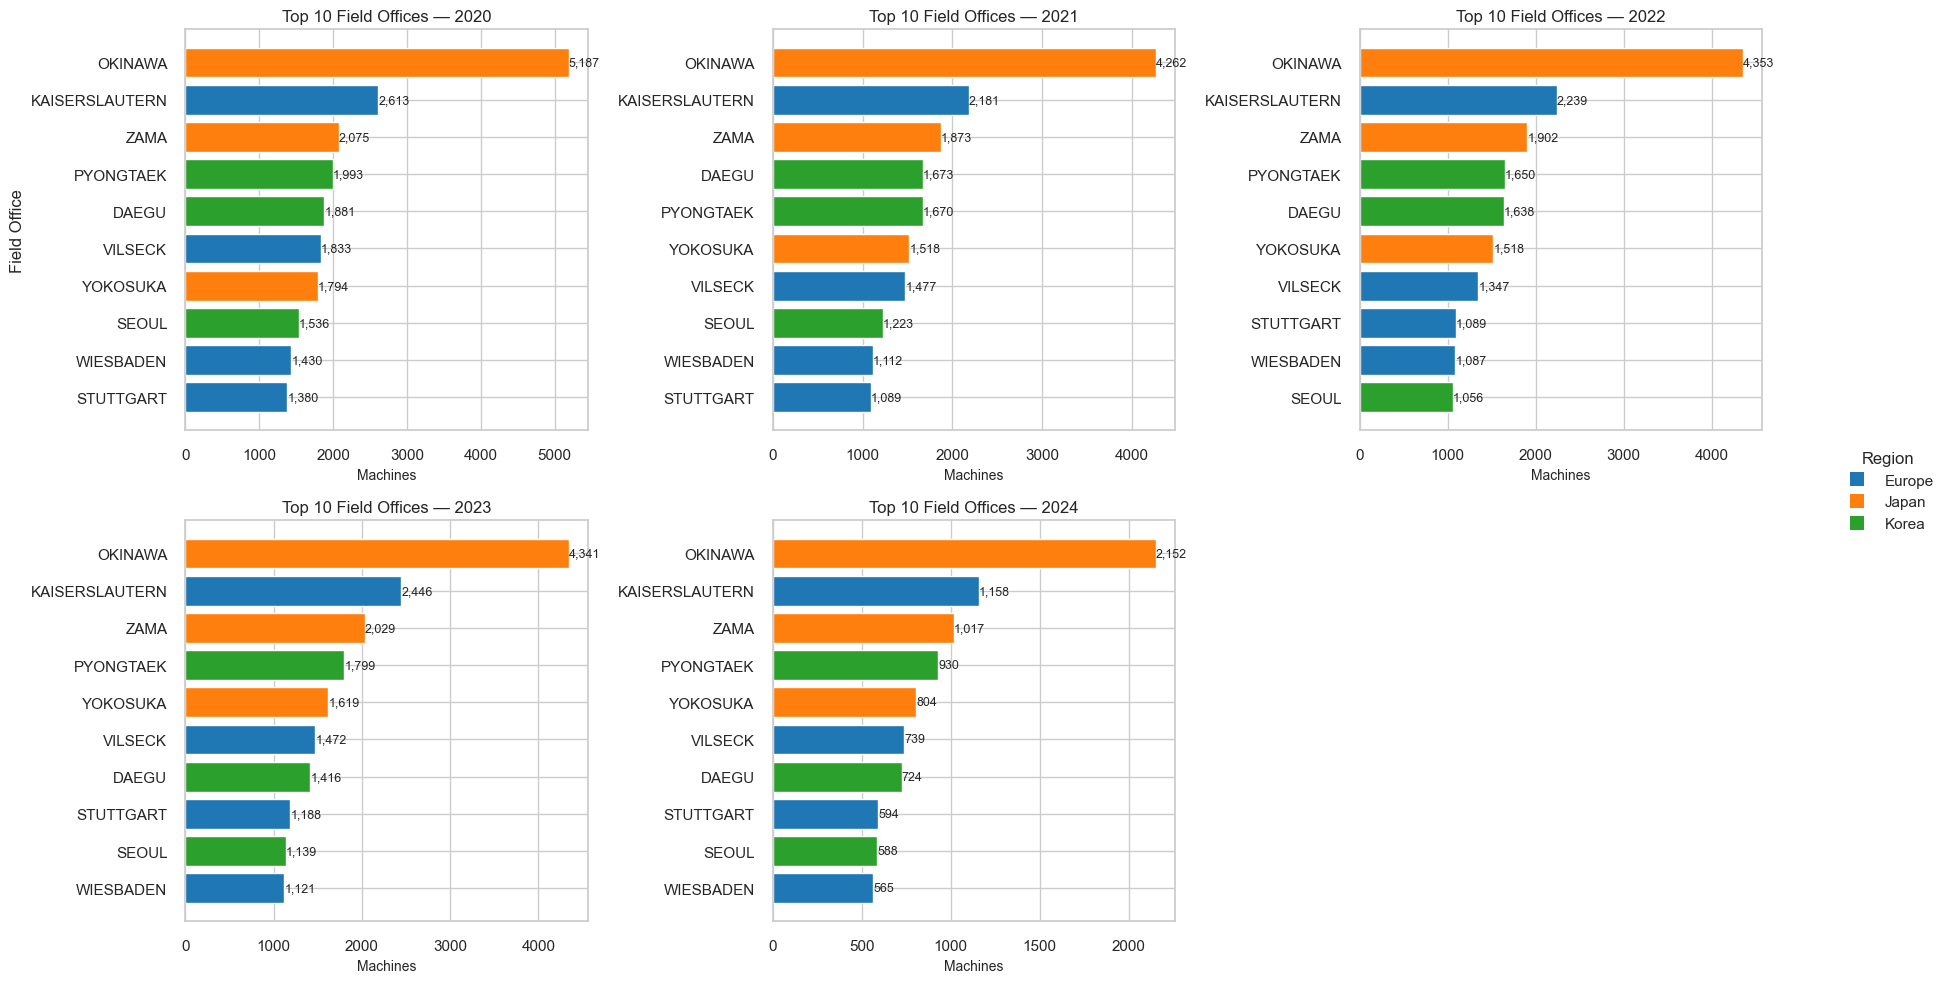

In [84]:
plot_top10_field_offices_multi_year(eda_df)

##### 8.1.1 Pie Plot of Total Gambling Machines Installed by Region

This visualization shows how the total number of installed gambling machines is distributed across the three reporting regions (Europe, Japan, Korea) aggregates all field offices in the most recent reporting year, giving the latest overall regional footprint of the machine network.

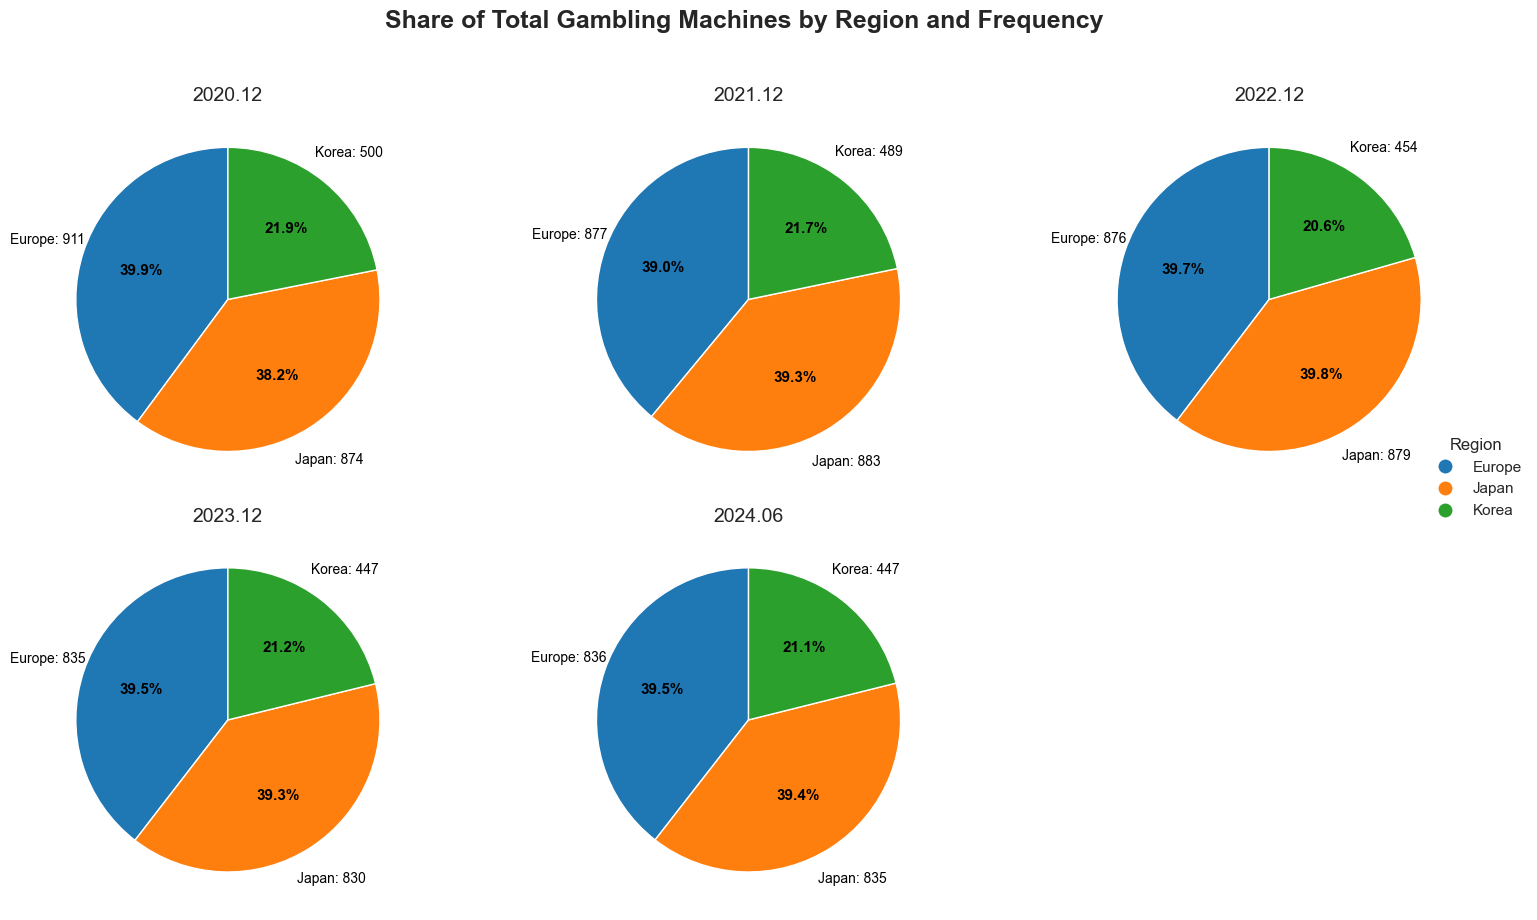

In [103]:
import numpy as np

valid_regions = ["Europe", "Japan", "Korea"]
df_clean = eda_df[eda_df["Region"].isin(valid_regions)].copy()

region_colors = {
    "Europe": "#1f77b4",
    "Japan":  "#ff7f0e",
    "Korea":  "#2ca02c",
}

def snapshot_year(df, year):
    """
    Return region totals for the last reporting date of that year.
    """
    df_year = df[df["Year"] == year]
    if df_year.empty:
        return None, None

    last_date = df_year["Reporting_Date"].max()
    snap = df_year[df_year["Reporting_Date"] == last_date]
    return snap.groupby("Region")["Total"].sum(), last_date


years_to_plot = [2020, 2021, 2022, 2023, 2024]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, yr in zip(axes, years_to_plot):

    region_totals, last_date = snapshot_year(df_clean, yr)

    if region_totals is None or region_totals.sum() == 0:
        ax.axis("off")
        continue

    values = region_totals.values
    labels = region_totals.index.tolist()
    colors = [region_colors[r] for r in labels]

    # Title format: YYYY.MM
    title_label = f"{last_date.year}.{last_date.month:02d}"

    def autopct_percent(pct):
        return f"{pct:.1f}%"

    wedges, inside_text, _ = ax.pie(
        values,
        colors=colors,
        startangle=90,
        autopct=autopct_percent,
        textprops={"fontsize": 11, "color": "black", "weight": "bold"},
    )

    # Outside labels: "Region: MachineCount"
    for wedge, label, val in zip(wedges, labels, values):
        theta = 0.5 * (wedge.theta1 + wedge.theta2)
        theta_rad = np.deg2rad(theta)

        r = 1.25
        x = r * np.cos(theta_rad)
        y = r * np.sin(theta_rad)

        ax.annotate(
            f"{label}: {val:,}",
            xy=(x, y),
            ha="center", va="center",
            fontsize=10, color="black"
        )

    ax.set_title(title_label, fontsize=14)

    

# Turn off extra subplot if fewer than 6 years
for extra_ax in axes[len(years_to_plot):]:
    extra_ax.axis("off")

# === Global Figure Title (your request) ===
fig.suptitle(
    "Share of Total Gambling Machines by Region and Frequency",
    fontsize=18, fontweight="bold", y=1.02
)

# Legend
legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor=color, markersize=10, label=region)
    for region, color in region_colors.items()
]

fig.legend(
    handles=legend_handles,
    title="Region",
    bbox_to_anchor=(0.92, 0.5),
    loc="center left",
)

plt.subplots_adjust(right=0.88)
plt.tight_layout()
plt.show()


##### 8.1.2 Pie Plot of Total Gambling Machines Installed by Region and Machine Type

##### 8.1.3 Timeseries Plot of Total Gambling  Machines Installed by Region and Frequency

##### 8.1.4 Indexed Timeseries Plot of Total Gambling  Machines Installed by Region and Frequency

##### 8.1.5 Bar Plot of Total Gambling Machines Installed by Machine Type

##### 8.1.6 Bar Plot of Net Change in Total Gambling Machines by Frequency

##### 8.1.7 Bubble Map of Machine Type Shares vs Total Shares by Frequency and Region

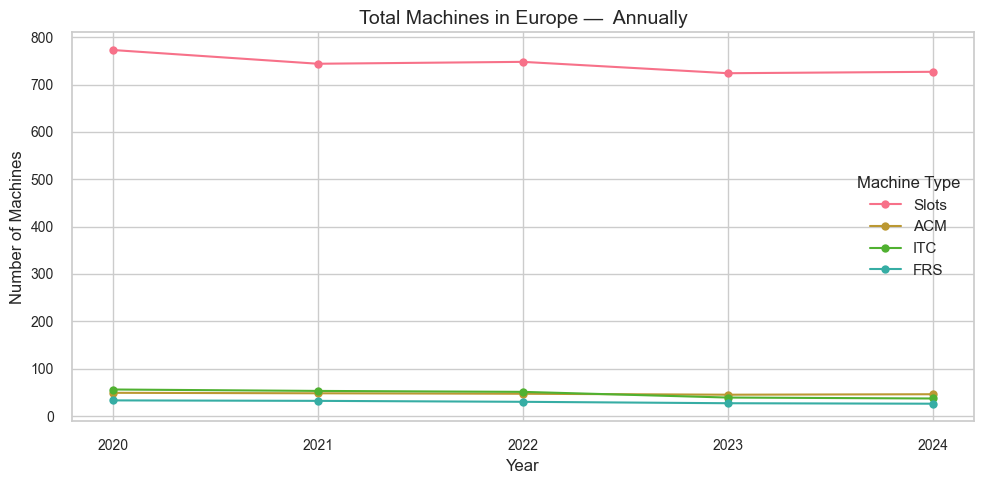

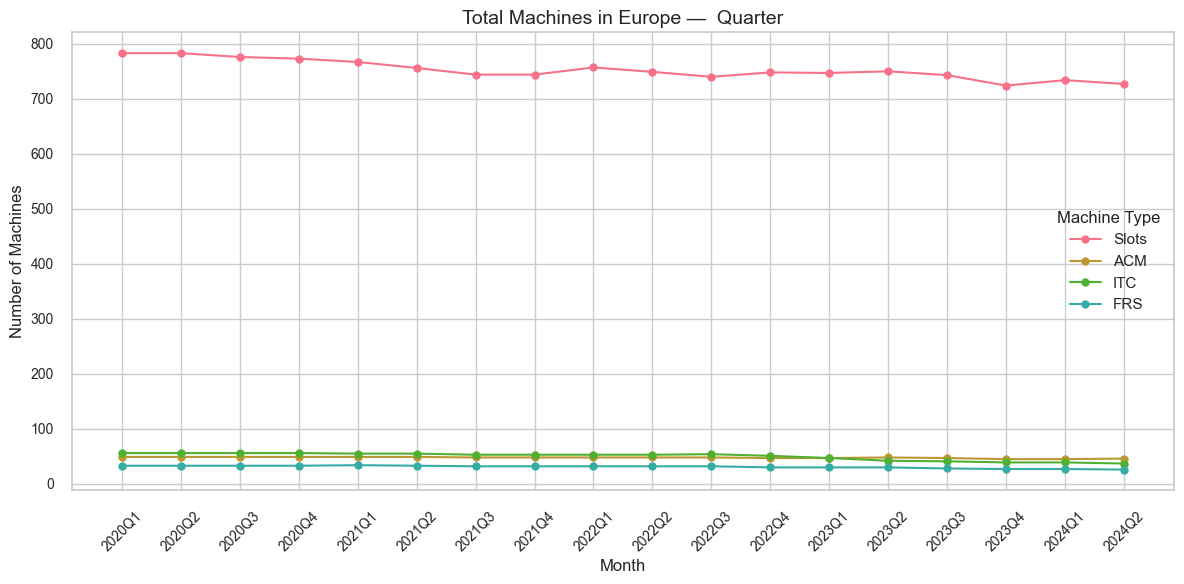

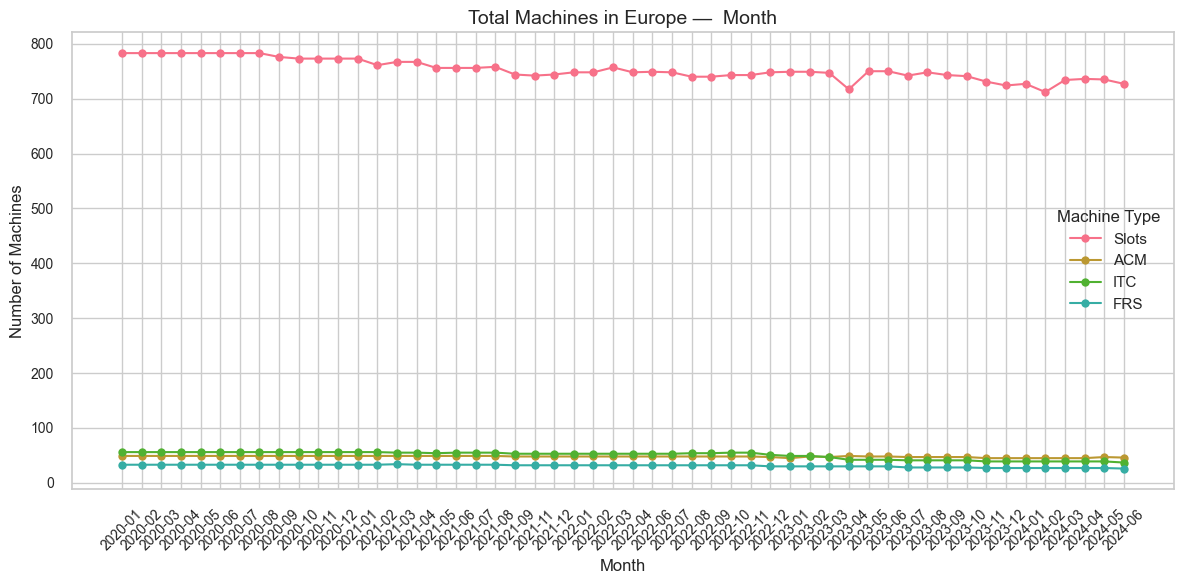

In [51]:
# Plot
plot_snapshot_timeseries(eu_machines_all_year, freq_label="Annually", region="Europe")
plot_snapshot_timeseries(eu_machines_all_quarter, freq_label="Quarter", region="Europe")
plot_snapshot_timeseries(eu_machines_all_month, freq_label="Month", region="Europe")

In [182]:
europe_yearly, europe_quarterly, europe_monthly = summarize_by_region(df, "Europe")



=== Snapshots for region: Europe ===
Year-level snapshot (last reporting month of each year):


,Slots,ACM,ITC,FRS,Total
Year,,,,,
2020,773,49,56,33,911
2021,1488,96,106,64,1754
2022,748,47,51,30,876
2023,724,45,39,27,835
2024,727,46,37,26,836



Quarter-level snapshot (last reporting date of each quarter):


,Slots,ACM,ITC,FRS,Total
Quarter,,,,,
2020Q1,783,49,56,33,921
2020Q2,783,49,56,33,921
2020Q3,776,49,56,33,914
2020Q4,773,49,56,33,911
2021Q1,767,49,55,34,905



Month-level snapshot (last reporting date of each month):


,Slots,ACM,ITC,FRS,Total
Month,,,,,
2020-01,783,49,56,33,921
2020-02,783,49,56,33,921
2020-03,783,49,56,33,921
2020-04,783,49,56,33,921
2020-05,783,49,56,33,921


##### 7.2.2 Plots and Visualization by Time

After preparing the dataset by converting dates, parsing machine counts, and calculating total machines per field office, we next summarize the data by Year and by Quarter.

It is important to note that:
- the totals shown for each year are not the `sum` of all monthly reports.
- instead, each field office typically reports once per month, and the dataset contains the most recent snapshot available for each reporting period.
- therefore, the `Total` for a given year or quarter reflects the snapshot from the final reporting month within that period, not a cumulative annual `sum`.

This aligns with the structure of the asset reports: they present installed machine counts at the time of reporting, not incremental additions. As a result, the aggregated yearly or quarterly totals represent the state of deployed machines, not cumulative machine installations throughout the year.

#### 7.1 Quarterly Trends in Installed Machines  

We aggregate machine totals (`Slots`, `ACM`, `ITC`, `FRS`) by quarter to visualize how installed machine counts evolve across the full fiscal years 2020 to 2024 period. This reveals the seasonality and growth patterns of different machine types.  

In [ ]:
# Create quarter variable
df["Quarter"] = df["Reporting_Date"].dt.to_period("Q")

quarterly = (
    df.groupby("Quarter")[machine_cols]
      .sum()
      .sort_index()
)

fig, ax = plt.subplots(figsize=FIGSIZE_LANDSCAPE)

x_labels = quarterly.index.astype(str)

for col in machine_cols:
    ax.plot(x_labels, quarterly[col], marker="o", label=col)

ax.legend(title="Machine type")
finalize_plot(
    title="Installed Machines by Type Over Time (Quarterly, All Field Offices)",
    xlabel="Quarter",
    ylabel="Number of machines",
    rotate_xticks=45,
)

plt.show()

In [ ]:

# 3.1 Load cleaned dataset from pipeline (or from CSV if needed)



try:
    # Use the dataframe created in the cleaning section
    df = all_records_df.copy()
    print("Using in-memory cleaned Format 1 dataset (all_records_df).")
except NameError:
    # Fallback: load from the exported CSV path defined earlier
    print("all_records_df not found, loading from CSV instead.")
    df = pd.read_csv(asset_report_fmt1_path)

# Basic prep
df["Reporting_Date"] = pd.to_datetime(df["Reporting_Date"], errors="coerce")
df = df.dropna(subset=["Reporting_Date"])
df["Year"] = df["Reporting_Date"].dt.year

machine_cols = ["Slots", "ACM", "ITC", "FRS"]
df[machine_cols] = df[machine_cols].apply(pd.to_numeric, errors="coerce")
df["Total"] = df[machine_cols].sum(axis=1)

print(df[["Reporting_Date", "Year", "Region"] + machine_cols + ["Total"]].head())


### Format 4

In [ ]:
print("Shape:", ar4.shape)
ar4.head()

In [ ]:
#Data Cleaning and Feature Engineering
ar4["FY_int"] = pd.to_numeric(ar4["FY"], errors="coerce").astype("Int64")

ar4["Aquire_dt"] = pd.to_datetime(ar4["Aquire"], errors="coerce")
ar4["Year_acquire"] = ar4["Aquire_dt"].dt.year


ar4["Type_str"] = ar4["Type"].astype(str)


def extract_cat_from_foshort(x):
    x = str(x).upper().strip()
    if x.endswith(" SLOT"):
        return "SLOT"
    if x.endswith(" FRS"):
        return "FRS"
    if "ACM" in x or "ITC" in x:
        return "ACM/ITC"
    return None  


foshort_cat = ar4["FOSHORT"].apply(extract_cat_from_foshort)



def clean_base(x):
    x = str(x).strip()
    x = x.replace(" SLOT", "").replace(" FRS", "")
    x = x.replace(" ACM/ITC", "").replace(" ACM", "").replace(" ITC", "")
    return x.strip()

ar4["Base_clean"] = ar4["FOSHORT"].astype(str).apply(clean_base)

ar4["Base_clean"] = ar4["Base_clean"].str.replace(r"^SOUDA$", "SOUDA BAY", regex=True, case=False)

original_cat = ar4["Cat"].astype(str).str.strip().str.upper().replace("NAN", None)

ar4["Cat_clean"] = foshort_cat.copy()

ar4["Cat_clean"] = ar4["Cat_clean"].fillna(original_cat)

ar4["Cat_clean"] = ar4["Cat_clean"].replace("NAN", pd.NA)

ar4[["FOSHORT", "Base_clean", "Cat", "Cat_clean"]].head()

In [ ]:
print("Category (Cat_clean) distribution:")
print(ar4["Cat_clean"].value_counts(dropna=False).head(10))

print("\nFiscal years present:")
print(ar4["FY_int"].value_counts().sort_index())

print("\nSample of Base vs Category:")
print(ar4[["Base_clean", "Cat_clean"]].drop_duplicates().head(15))


In [ ]:
# Category-Level Trend Over Time (SLOT vs FRS vs ACM/ITC)
main_cats = ["SLOT", "FRS", "ACM/ITC"]

cat_filtered = ar4[
    ar4["Cat_clean"].isin(main_cats) & ar4["FY_int"].notna()
]

cat_year = (
    cat_filtered
    .groupby(["Cat_clean", "FY_int"])
    .size()
    .reset_index(name="count")
)

cat_year

In [ ]:
# Plotting the trends
plt.figure(figsize=(10, 5))

for cat in main_cats:
    sub = cat_year[cat_year["Cat_clean"] == cat]
    if sub.empty:
        continue
    plt.plot(sub["FY_int"], sub["count"], marker="o", label=cat)

plt.xlabel("Fiscal Year")
plt.ylabel("Number of Machines")
plt.title("Trend of Categories (SLOT / FRS / ACM/ITC) Over Fiscal Years")
plt.xticks(sorted(cat_year["FY_int"].dropna().unique()))
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Trend Lines for Top Machine Types
def most_common_cat(x):
    x_nonnull = x.dropna()
    if x_nonnull.empty:
        return "UNKNOWN"     # fallback when no category is available for this type
    return x_nonnull.value_counts().idxmax()

type_cat_map = (
    ar4.groupby("Type_str")["Cat_clean"]
      .apply(most_common_cat)
      .to_dict()
)


In [ ]:
# Build type-year table across all bases
type_year = (
    ar4.dropna(subset=["FY_int"])
      .groupby(["Type_str", "FY_int"])
      .size()
      .reset_index(name="count")
)

# Select TOP N machine types overall
TOP_N = 5
top_types = (
    type_year.groupby("Type_str")["count"]
             .sum()
             .nlargest(TOP_N)
             .index
)

plot_data = type_year[type_year["Type_str"].isin(top_types)]


plt.figure(figsize=(12, 6))

for t in top_types:
    sub = plot_data[plot_data["Type_str"] == t]
    cat = type_cat_map.get(t, "UNKNOWN")
    label = f"Type {t} – {cat}"
    plt.plot(sub["FY_int"], sub["count"], marker="o", label=label)

plt.xlabel("Fiscal Year")
plt.ylabel("Number of Machines")
plt.title("Trend of Top Machine Types Over Time (with Category from Cat_clean)")
plt.xticks(sorted(plot_data["FY_int"].dropna().unique()))
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Acquisition-Based Category Trend
acq_cat = (
    ar4.dropna(subset=["Year_acquire"])  
      .groupby(["Cat_clean", "Year_acquire"])
      .size()
      .reset_index(name="count")
)

acq_cat_main = acq_cat[acq_cat["Cat_clean"].isin(main_cats)]

plt.figure(figsize=(10, 5))

for cat in main_cats:
    sub = acq_cat_main[acq_cat_main["Cat_clean"] == cat]
    if sub.empty:
        continue
    plt.plot(sub["Year_acquire"], sub["count"], marker="o", label=cat)

plt.xlabel("Acquisition Year")
plt.ylabel("Machines Acquired")
plt.title("Acquisition Trend by Category (SLOT / FRS / ACM/ITC)")
plt.xticks(sorted(acq_cat_main["Year_acquire"].dropna().unique()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Machine Category Trends for Specific Bases
def plot_all_categories_for_base(df, base_name, region_name=None):
    """
    Plots SLOT, FRS, and ACM/ITC machine trends on the SAME graph
    for a specific base across all fiscal years.
    If region_name is provided, it will be added to the title.
    """

    categories = ["SLOT", "FRS", "ACM/ITC"]
    colors = ["blue", "orange", "green"]

    plt.figure(figsize=(10,5))

    found_any = False

    for cat, color in zip(categories, colors):
        base_cat = ar4[
            (df["Base_clean"] == base_name) &
            (df["Cat_clean"] == cat)
        ]

        if base_cat.empty:
            continue  
        found_any = True

        
        trend = (
            base_cat.groupby("FY_int")
                    .size()
                    .reset_index(name=f"{cat}_count")
                    .sort_values("FY_int")
        )

        plt.plot(
            trend["FY_int"],
            trend[f"{cat}_count"],
            marker="o",
            linewidth=2,
            color=color,
            label=cat
        )

    if not found_any:
        print(f"No SLOT/FRS/ACM/ITC data for base: {base_name}")
        plt.close()
        return

    if region_name:
        title = f"Machine Category Trends Over Years – {base_name} ({region_name})"
    else:
        title = f"Machine Category Trends Over Years – {base_name}"

    plt.title(title)
    plt.xlabel("Fiscal Year")
    plt.ylabel("Number of Machines count")
    plt.xticks(sorted(ar4["FY_int"].dropna().unique()))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
plot_all_categories_for_base(ar4, "KAISERSLAUTERN")

In [ ]:
# Region and Base Analysis
print(ar4["REGION"].value_counts())
print(ar4[["REGION", "Base_clean"]].head())

base_region_counts = (
    ar4.dropna(subset=["REGION", "Base_clean"])
      .groupby(["REGION", "Base_clean"])
      .size()
      .reset_index(name="machine_count")
)

# top 5 bases by machine count
top_bases_per_region = (
    base_region_counts
    .sort_values(["REGION", "machine_count"], ascending=[True, False])
    .groupby("REGION")
    .head(5)
)

top_bases_per_region

In [ ]:
# Mapping regions to their top bases
region_to_bases = (
    top_bases_per_region
    .groupby("REGION")["Base_clean"]
    .apply(list)
    .to_dict()
)

region_to_bases


In [ ]:
# Plotting for each region and its top bases
for region, base_list in region_to_bases.items():
    print(f"\n=== Region: {region} ===")
    for base in base_list:
        print(f"Plotting for base: {base}")
        plot_all_categories_for_base(ar4, base, region_name=region)

In [ ]:
# Slot Machine Count Per Base Per Year

slot_df = ar4[ar4["Cat_clean"] == "SLOT"].copy()

slot_base_year_table = (
    slot_df
    .dropna(subset=["Base_clean", "FY_int"])
    .groupby(["Base_clean", "FY_int"])
    .size()
    .reset_index(name="slot_count")
    .pivot(index="Base_clean", columns="FY_int", values="slot_count")
    .fillna(0)
    .astype(int)
)

slot_base_year_table


In [ ]:
# Machine Distribution by branch
ar4["SVC_clean"] = (
    ar4["SVC"]
    .astype(str)
    .str.extract(r"(Army|Navy|Marine Corps)", expand=False)
)

branch_counts = ar4["SVC_clean"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    branch_counts,
    labels=branch_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title("Machine Distribution Across Army, Navy, and Marine Corps")
plt.show()

In [ ]:
# Slot Machine Distribution by branch
slot_df = ar4[ar4["Cat_clean"] == "SLOT"]

slot_branch_counts = slot_df["SVC_clean"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    slot_branch_counts,
    labels=slot_branch_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title("SLOT Machine Distribution Across Army, Navy, and Marine Corps")
plt.show()


In [ ]:
# Count how many distinct machine Types exist each Fiscal Year
types_per_year = (
    ar4.dropna(subset=["FY_int", "Type_str"])
      .groupby("FY_int")["Type_str"]
      .nunique()
      .reset_index(name="unique_types")
      .sort_values("FY_int")
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(types_per_year["FY_int"], types_per_year["unique_types"], marker="o", linewidth=2)
plt.title("Trend in Number of Unique Machine Types Over Years")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Unique Machine Types")
plt.xticks(types_per_year["FY_int"])
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Unique Machine Types Per Base Over Time
def plot_unique_types_per_base(df, base_name):
    base_df = ar4[df["Base_clean"] == base_name]

    types_year = (
        base_df.dropna(subset=["FY_int", "Type_str"])
               .groupby("FY_int")["Type_str"]
               .nunique()
               .reset_index(name="unique_types")
               .sort_values("FY_int")
    )

    if types_year.empty:
        print(f"No data for base: {base_name}")
        return

    plt.figure(figsize=(8,4))
    plt.plot(types_year["FY_int"], types_year["unique_types"], marker="o")
    plt.title(f"Unique Machine Types Over Years – {base_name}")
    plt.xlabel("Fiscal Year")
    plt.ylabel("Number of Types")
    plt.xticks(types_year["FY_int"])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_unique_types_per_base(ar4, "KAISERSLAUTERN")
plot_unique_types_per_base(ar4, "SOUDA BAY")


### Format 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Path to the CSV (update this to your actual path if needed)
csv_path = "/Users/howardhuntermckeon/Desktop/final version of format 2/Asset Report FY20-FY24 Format 2.csv"

df = pd.read_csv(csv_path)
df.head()

In [ ]:
# Define provider and related numeric columns
provider_cols = ["NOV", "AIN", "IGT", "WMS", "BAL", "KON", "ITE"]
numeric_cols = provider_cols + ["Tot/EGMs", "FRS", "DIE", "COU", "ACM", "ITC", "Total"]

# Replace '-' with 0 and convert to numeric
df[numeric_cols] = (
    df[numeric_cols]
    .replace("-", 0)
    .apply(pd.to_numeric, errors="coerce")
)

print("Data types for key columns:")
print(df[numeric_cols].dtypes)

print("\nProvider column totals (sanity check):")
print(df[provider_cols].sum())

In [ ]:
# 1. Total machines per provider (overall)

total_by_provider = df[provider_cols].sum().sort_values(ascending=False)
print("Total machines by provider (FY20–FY24):")
display(total_by_provider.to_frame(name="Total Machines"))

plt.figure()
total_by_provider.plot(kind="bar")
plt.ylabel("Total machine count")
plt.title("Total Slot Machines per Provider (FY20–FY24)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Provider market share by year

provider_by_year = df.groupby("Year")[provider_cols].sum()
print("Provider totals by year:")
display(provider_by_year)

provider_share_by_year = provider_by_year.div(provider_by_year.sum(axis=1), axis=0)
print("\nProvider market share by year:")
display(provider_share_by_year)

plt.figure()
for col in provider_cols:
    plt.plot(provider_by_year.index, provider_by_year[col], marker="o", label=col)

plt.xlabel("Year")
plt.ylabel("Total machine count")
plt.title("Provider Totals by Year")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.stackplot(
    provider_share_by_year.index,
    [provider_share_by_year[col] for col in provider_cols],
    labels=provider_cols
)
plt.xlabel("Year")
plt.ylabel("Share of provider machines")
plt.title("Provider Market Share by Year")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# 3. Provider distribution by region

provider_by_region = df.groupby("Region")[provider_cols].sum()
print("Provider totals by region:")
display(provider_by_region)

provider_share_by_region = provider_by_region.div(provider_by_region.sum(axis=1), axis=0)
print("\nProvider share by region:")
display(provider_share_by_region)

plt.figure()
bottom = None
for col in provider_cols:
    if bottom is None:
        bottom = provider_share_by_region[col]
        plt.bar(provider_share_by_region.index, provider_share_by_region[col])
    else:
        plt.bar(provider_share_by_region.index, provider_share_by_region[col], bottom=bottom)
        bottom = bottom + provider_share_by_region[col]

plt.ylabel("Share of provider machines")
plt.title("Provider Mix by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Trend analysis: Tot/EGMs and provider concentration over time

egms_by_year = df.groupby("Year")["Tot/EGMs"].sum()
print("Total EGMs by year:")
display(egms_by_year.to_frame(name="Total EGMs"))

plt.figure()
egms_by_year.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Total EGMs")
plt.title("Total EGMs by Year")
plt.tight_layout()
plt.show()

top_share_by_year = provider_share_by_year.max(axis=1)
plt.figure()
top_share_by_year.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Share")
plt.title("Share of Dominant Provider by Year")
plt.tight_layout()
plt.show()

In [ ]:
# 5. Location-level diversity: how many distinct providers per row?

def count_nonzero_providers(row):
    return (row[provider_cols] > 0).sum()

df["num_providers"] = df.apply(count_nonzero_providers, axis=1)

print("Summary of number of providers per row:")
display(df["num_providers"].describe().to_frame(name="num_providers"))

providers_per_region = df.groupby("Region")["num_providers"].mean()
print("\nAverage number of providers per location by region:")
display(providers_per_region.to_frame(name="Average Providers"))

plt.figure()
providers_per_region.plot(kind="bar")
plt.ylabel("Average # of providers per location")
plt.title("Provider Diversity by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Biggest provider in each region

region_totals = df.groupby("Region")[provider_cols].sum()

biggest_provider_region = pd.DataFrame({
    "Top Provider": region_totals.idxmax(axis=1),
    "Machines": region_totals.max(axis=1)
}).sort_values("Machines", ascending=False)

print("Biggest provider in each region:")
display(biggest_provider_region)

plt.figure()
biggest_provider_region["Machines"].plot(kind="bar")
plt.ylabel("Machines (top provider)")
plt.title("Top Provider Machine Count by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 7. Bases with the highest total number of machines (Tot/EGMs)

top_bases = (
    df[["Country", "LOC", "Region", "Tot/EGMs"]]
    .sort_values("Tot/EGMs", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 bases by total EGMs:")
display(top_bases)

plt.figure()
plt.bar(top_bases["Country"].astype(str) + " (LOC " + top_bases["LOC"].astype(str) + ")", top_bases["Tot/EGMs"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Tot/EGMs")
plt.title("Top 10 Bases by Total EGMs")
plt.tight_layout()
plt.show()

In [ ]:
# 8. Location where each provider has its maximum machine count

max_rows = []

for provider in provider_cols:
    max_count = df[provider].max()
    subset = df[df[provider] == max_count]
    for _, row in subset.iterrows():
        max_rows.append({
            "Provider": provider,
            "Max Machines": max_count,
            "Country": row["Country"],
            "LOC": row["LOC"],
            "Region": row["Region"]
        })

provider_max_locations = pd.DataFrame(max_rows).drop_duplicates()
provider_max_locations = provider_max_locations.sort_values(["Provider", "Max Machines"], ascending=[True, False])

print("Location(s) where each provider has its highest machine count:")
display(provider_max_locations)

In [ ]:
# 9. Provider vs Region matrix (heatmap-style plot)

provider_by_region = df.groupby("Region")[provider_cols].sum()

print("Provider by Region matrix:")
display(provider_by_region)

plt.figure()
plt.imshow(provider_by_region.values, aspect="auto")
plt.colorbar(label="Machine count")
plt.xticks(range(len(provider_cols)), provider_cols, rotation=45)
plt.yticks(range(len(provider_by_region.index)), provider_by_region.index)
plt.title("Provider Counts by Region (Heatmap Style)")
plt.tight_layout()
plt.show()

In [ ]:
# 10. Simple map-style scatter for top 10 bases (requires latitude/longitude)

top_bases_geo = (
    df.dropna(subset=["latitude", "longitude"])
      .sort_values("Tot/EGMs", ascending=False)
      .head(10)
)

print("Top 10 bases with coordinates:")
display(top_bases_geo[["Country", "LOC", "Region", "Tot/EGMs", "latitude", "longitude"]])

plt.figure()
plt.scatter(top_bases_geo["longitude"], top_bases_geo["latitude"], s=top_bases_geo["Tot/EGMs"] * 2)
for _, row in top_bases_geo.iterrows():
    label = f"{row['Country']} ({row['Tot/EGMs']})"
    plt.text(row["longitude"], row["latitude"], label, fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 10 Bases by EGMs (Size ~ Tot/EGMs)")
plt.tight_layout()
plt.show()